# Raytracing Server Demo

This notebook demonstrates how to use the raytracing server to calculate obstruction angles.

**Note**: If you get import errors, restart the kernel: `Kernel > Restart Kernel`

In [1]:
import requests
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import sys
import importlib

# Add current directory to path
if '.' not in sys.path:
    sys.path.insert(0, '.')

# Import and reload to get latest changes
import viz_utils
importlib.reload(viz_utils)
from viz_utils import (DirectionVectorCalculator, ProjectionPlaneBuilder, MeshProjector, 
                       MeshRenderer, PlotElementRenderer, AxisConfigurator, VisualizationFactory)

## 1. Setup Server Connection

Start the server: `python -m src.main`

In [2]:
SERVER_URL = "http://localhost:8081"
response = requests.get(f"{SERVER_URL}/")
print("Server Status:", response.json())

Server Status: {'services': {'raytrace_service': {'obstruction_calculator': 'MaxHeightObstructionCalculator', 'projection_calculator': 'OrthographicProjectionCalculator', 'status': 'ready'}}, 'status': 'running'}


## 2. Define Scenario

Window at origin looking forward, building 10m away, 5m tall.

In [7]:
window_center = [0.0, 3.0, 0.0]
window_angles = [0.03, 0.0]  # Looking forward (+X)
building_dist, building_height, building_width = 10.0, 5.0, 10.0
mesh = [[building_dist, 0.0, -building_width/2], [building_dist, building_height, -building_width/2], [building_dist, 0.0, building_width/2],
        [building_dist, 0.0, building_width/2], [building_dist, building_height, -building_width/2], [building_dist, building_height, building_width/2]]
print(f"Window: {window_center}, Angles: {window_angles}")
print(f"Building: {building_dist}m away, {building_height}m tall, {building_width}m wide")

Window: [0.0, 3.0, 0.0], Angles: [0.03, 0.0]
Building: 10.0m away, 5.0m tall, 10.0m wide


## 3. Call Raytracing Server

In [8]:
request_data = {"x": window_center[0], 
                "y": window_center[1], 
                "z": window_center[2], 
                "rad_x": window_angles[0], 
                "rad_y": window_angles[1], 
                "mesh": mesh}
response = requests.post(f"{SERVER_URL}/raytrace", json=request_data)
result = response.json()
print("Result:", result)

Result: {'data': {'highest_point': {'x': 10.0, 'y': 5.0, 'z': -5.0}, 'obstruction_angle_degrees': 11.309932474020215, 'obstruction_angle_radians': 0.19739555984988078, 'projected_point_count': 6}, 'status': 'success'}


## 4. Results

In [9]:
if result.get("status") == "success":
    data = result["data"]
    obstruction_degrees, obstruction_radians, highest_point = data["obstruction_angle_degrees"], data["obstruction_angle_radians"], data["highest_point"]
    print(f"Obstruction: {obstruction_degrees:.2f}° ({obstruction_radians:.4f} rad)")
    if obstruction_degrees>0:
        print(f"Highest: ({highest_point['x']:.1f}, {highest_point['y']:.1f}, {highest_point['z']:.1f}), Points: {data['projected_point_count']}")
else:
    print("ERROR:", result.get("error"))

Obstruction: 11.31° (0.1974 rad)
Highest: (10.0, 5.0, -5.0), Points: 6


## 5. Visualization

**Note**: The projection plane shown is for visualization only. The actual calculation uses:
1. Find highest mesh vertex in front of window (Y-coordinate)
2. Calculate angle from window to that vertex
3. Angle = arctan(height_difference / horizontal_distance)

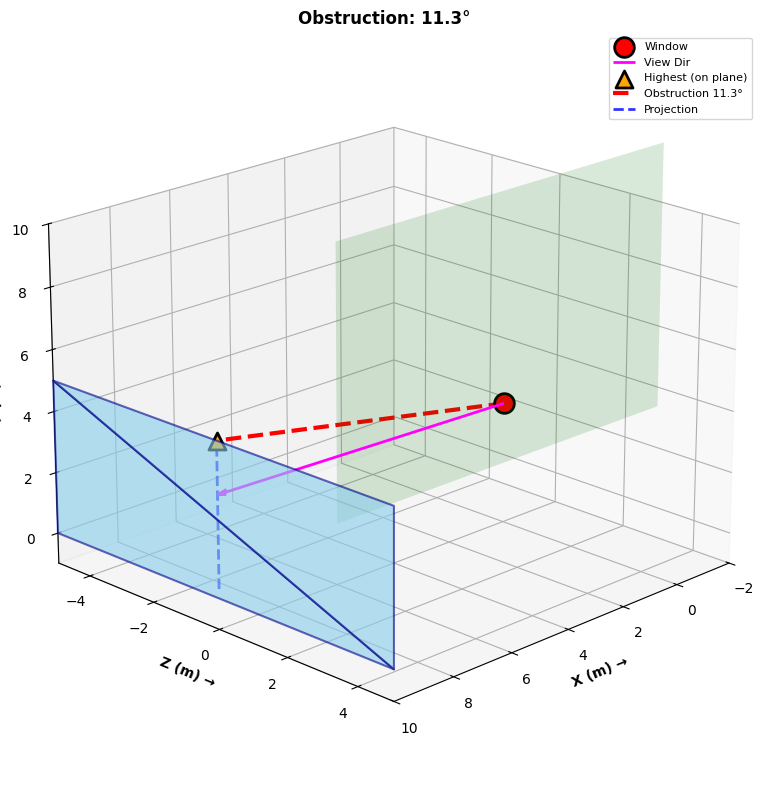

In [10]:
if result.get("status") == "success":
    # Create visualization components
    dir_vec, dir_h, plane_builder, mesh_projector = VisualizationFactory.create_projection_components(
        window_center, window_angles)
    
    fig = plt.figure(figsize=(14, 8))
    ax = fig.add_subplot(111, projection='3d')
    renderer = PlotElementRenderer()
    
    # Add all plot elements
    renderer.add_window(ax, window_center)
    renderer.add_mesh(ax, mesh)
    renderer.add_viewing_direction(ax, window_center, dir_vec, building_dist)
    renderer.add_projection_plane(ax, plane_builder, width=12, height_range=(-2, building_height+2))
    
    # Find highest point from server result
    if highest_point:
        hp_3d = np.array([highest_point['x'], highest_point['y'], highest_point['z']])
        # Project it onto the plane for visualization
        hp_proj = plane_builder.project_point(hp_3d)
        renderer.add_highest_point(ax, hp_proj)
        renderer.add_obstruction_line(ax, window_center, hp_proj, obstruction_degrees)
        renderer.add_projection_line(ax, dir_vec * building_dist, hp_proj)
    
    # Configure axes and display
    AxisConfigurator.setup(ax, max_range=max(building_dist, building_height, building_width),
                           title=f'Obstruction: {obstruction_degrees:.1f}°')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## 6. Test Scenarios

In [ ]:
calc = DirectionVectorCalculator()
combos = [(0,0,"Fwd"), (0,np.pi/2,"Right"), (0,np.pi,"Back"), 
          (0,-np.pi/2,"Left"), (np.pi/2,0,"Up"), (-np.pi/2,0,"Down")]
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter([0],[0],[0], c='k', s=60)
colors = plt.cm.rainbow(np.linspace(0, 1, len(combos)))
for (rx, ry, lbl), col in zip(combos, colors):
    v = calc.from_angles(rx, ry)
    ax.quiver(0, 0, 0, *v, color=col, lw=2, arrow_length_ratio=0.15, 
              label=f"{lbl}: ({v[0]:.2f}, {v[1]:.2f}, {v[2]:.2f})")
ax.set_xlabel('X')
ax.set_ylabel('Y ↑')
ax.set_zlabel('Z')
ax.set_title('Direction Vectors')
ax.legend(fontsize=7)
plt.show()

## 7. Direction Vectors

In [ ]:
scenarios = [{"distance": 5, "height": 5}, {"distance": 10, "height": 10}, {"distance": 20, "height": 5}]
print(f"{'Dist(m)':<10} {'Height(m)':<10} {'Angle(°)':<10} {'Expected(°)':<10}")
for s in scenarios:
    mesh_temp = [[s["distance"], 0, -5], [s["distance"], s["height"], -5], [s["distance"], 0, 5],
                 [s["distance"], 0, 5], [s["distance"], s["height"], -5], [s["distance"], s["height"], 5]]
    r = requests.post(f"{SERVER_URL}/raytrace", 
                      json={"x": 0, "y": 1.5, "z": 0, "rad_x": 0, "rad_y": 0, "mesh": mesh_temp}).json()
    if r.get("status") == "success":
        angle_calc = r['data']['obstruction_angle_degrees']
        angle_expected = np.degrees(np.arctan((s['height'] - 1.5) / s['distance']))
        print(f"{s['distance']:<10} {s['height']:<10} {angle_calc:<10.2f} {angle_expected:<10.2f}")
    else:
        print(f"{s['distance']:<10} {s['height']:<10} ERROR")